processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_7198/3003169814.py:93: RuntimeWarning: Mean of empty slice
  p_mean = np.nanmean(baseline_slice, axis=(0, 2))
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_7198/3003169814.py:117: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL


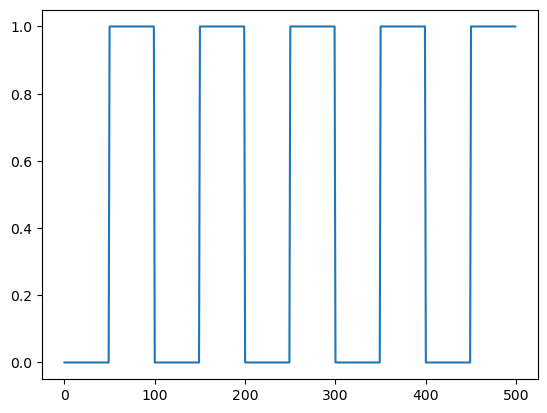

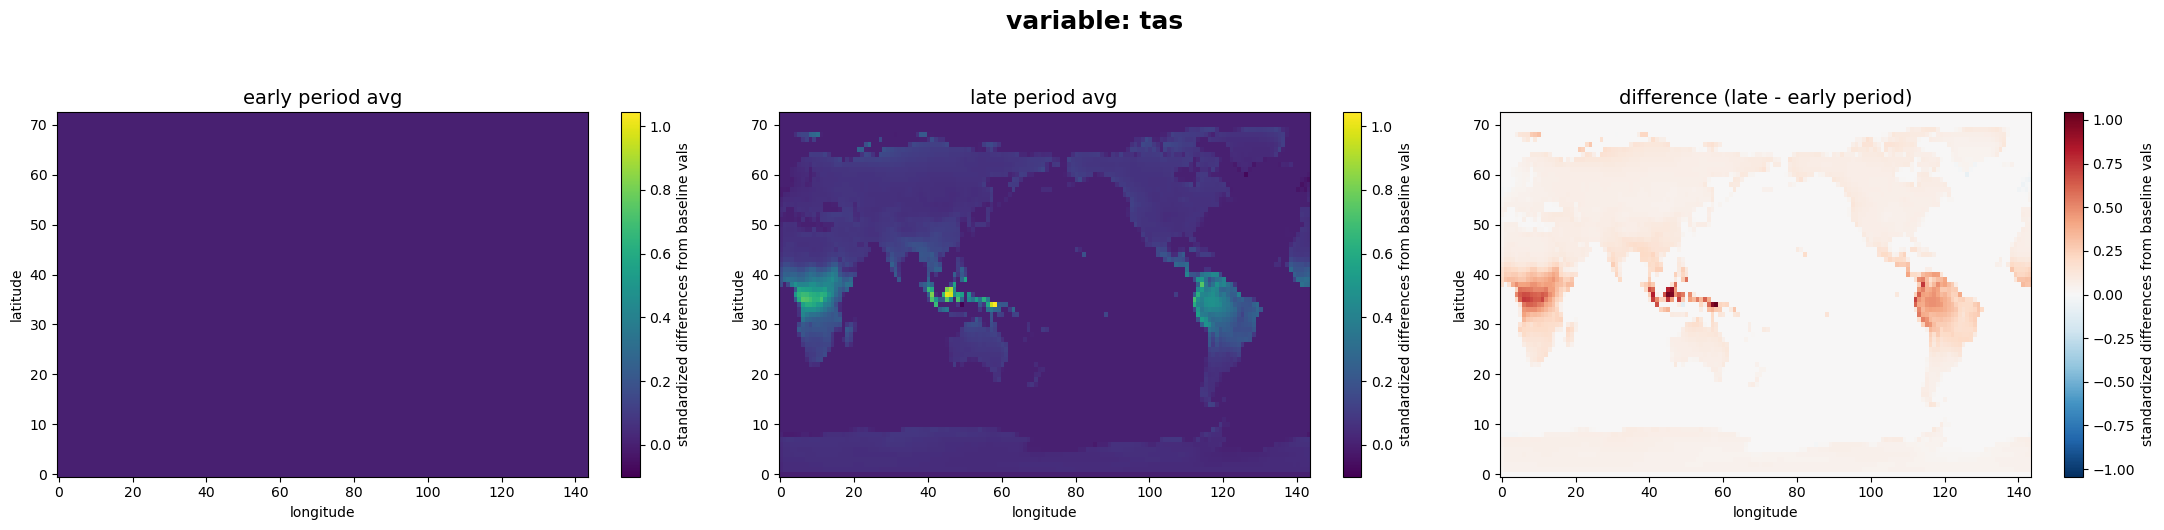

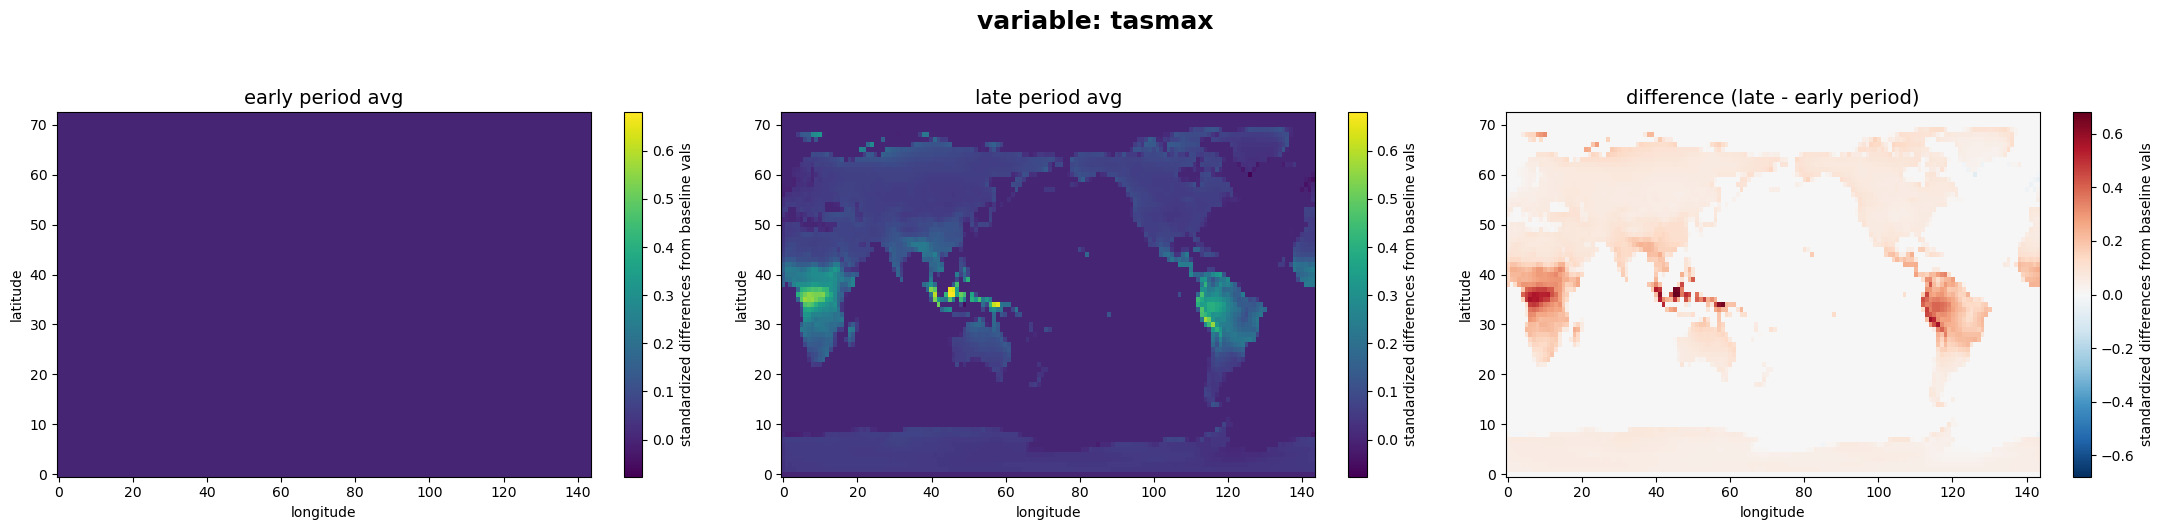

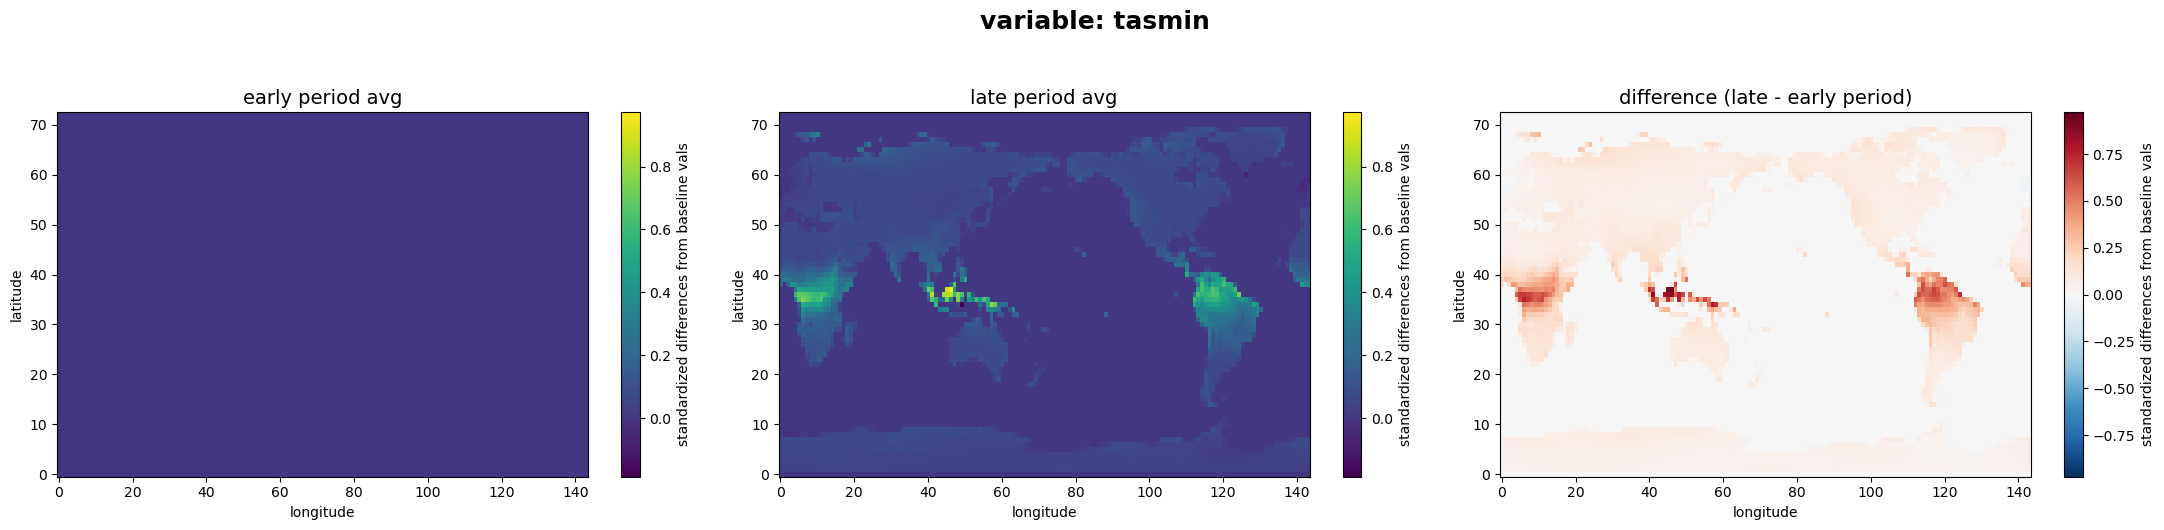

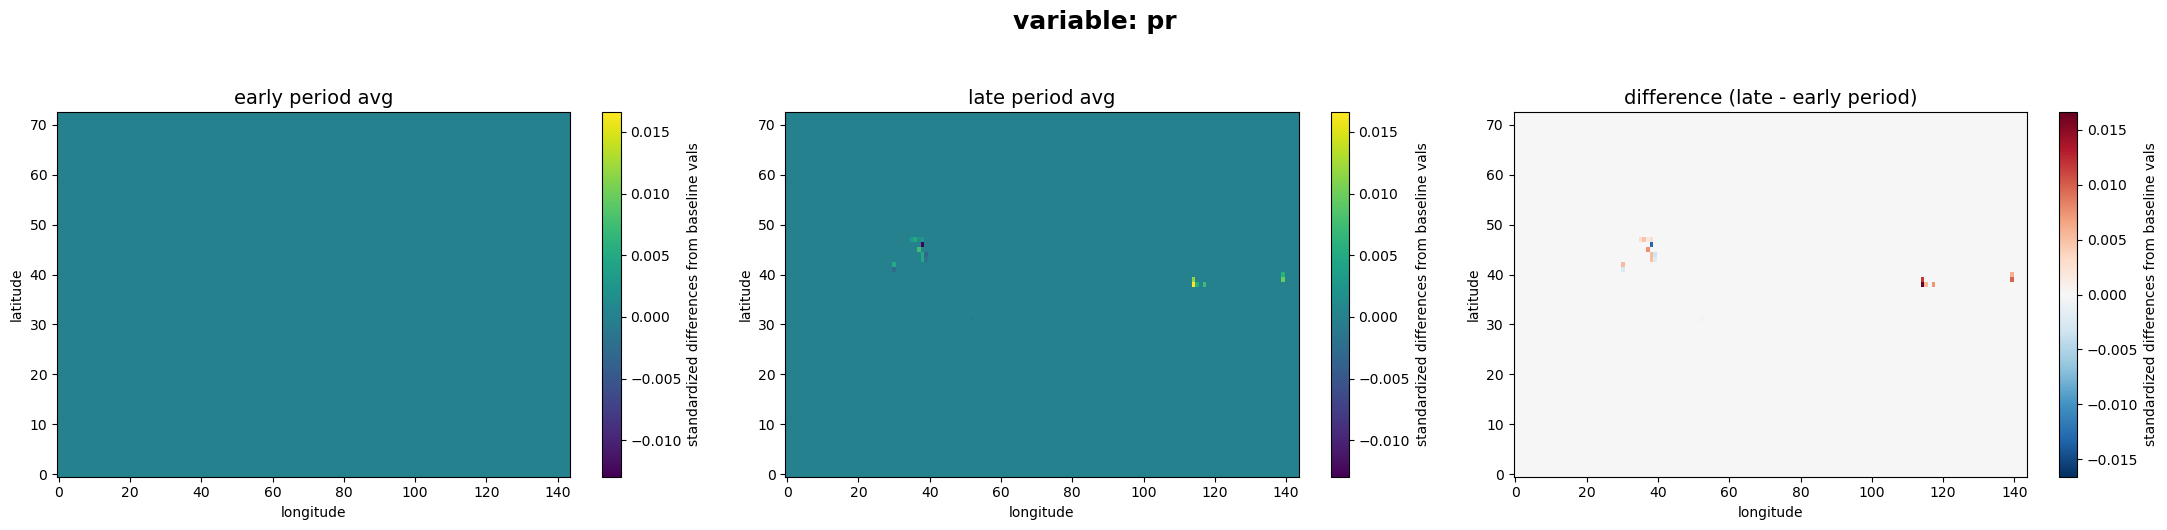

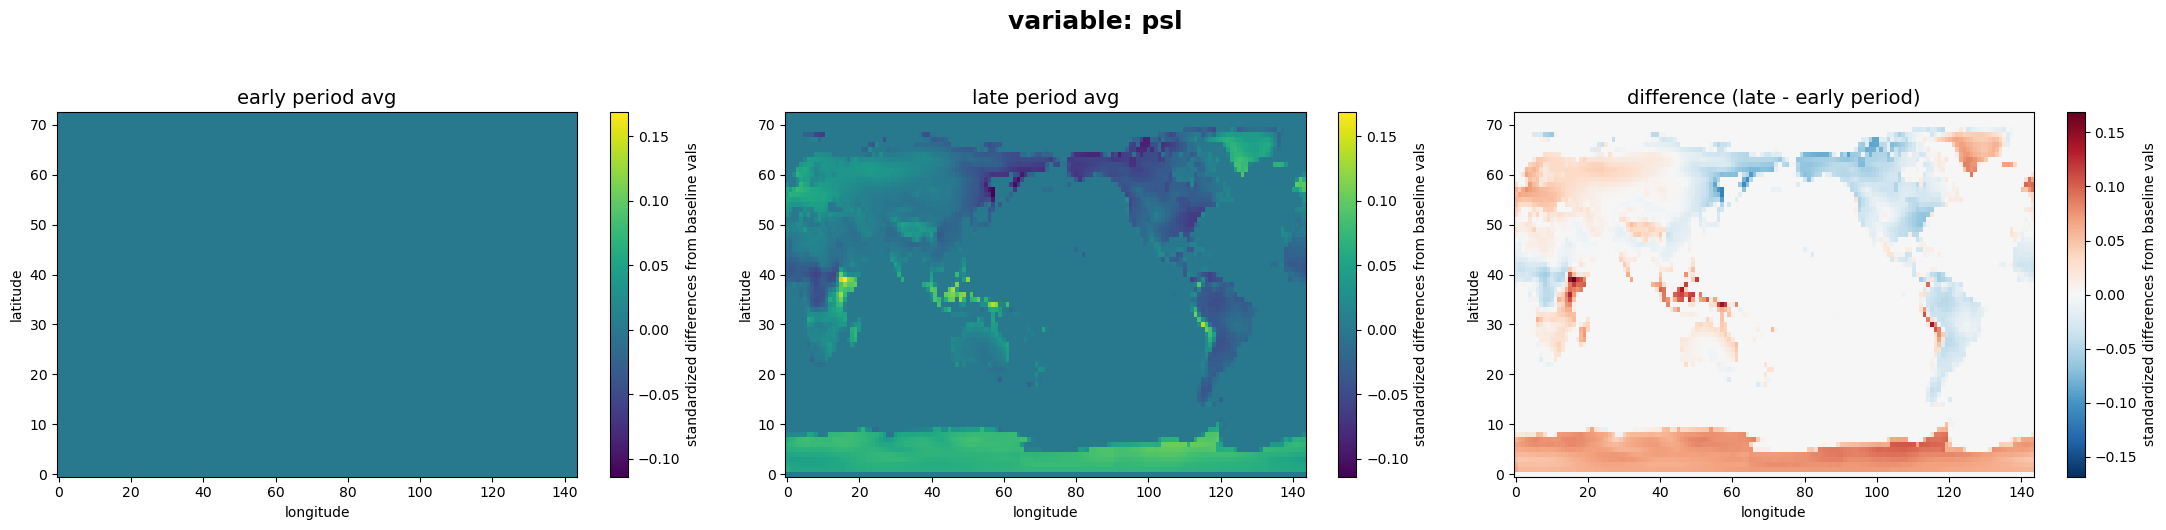

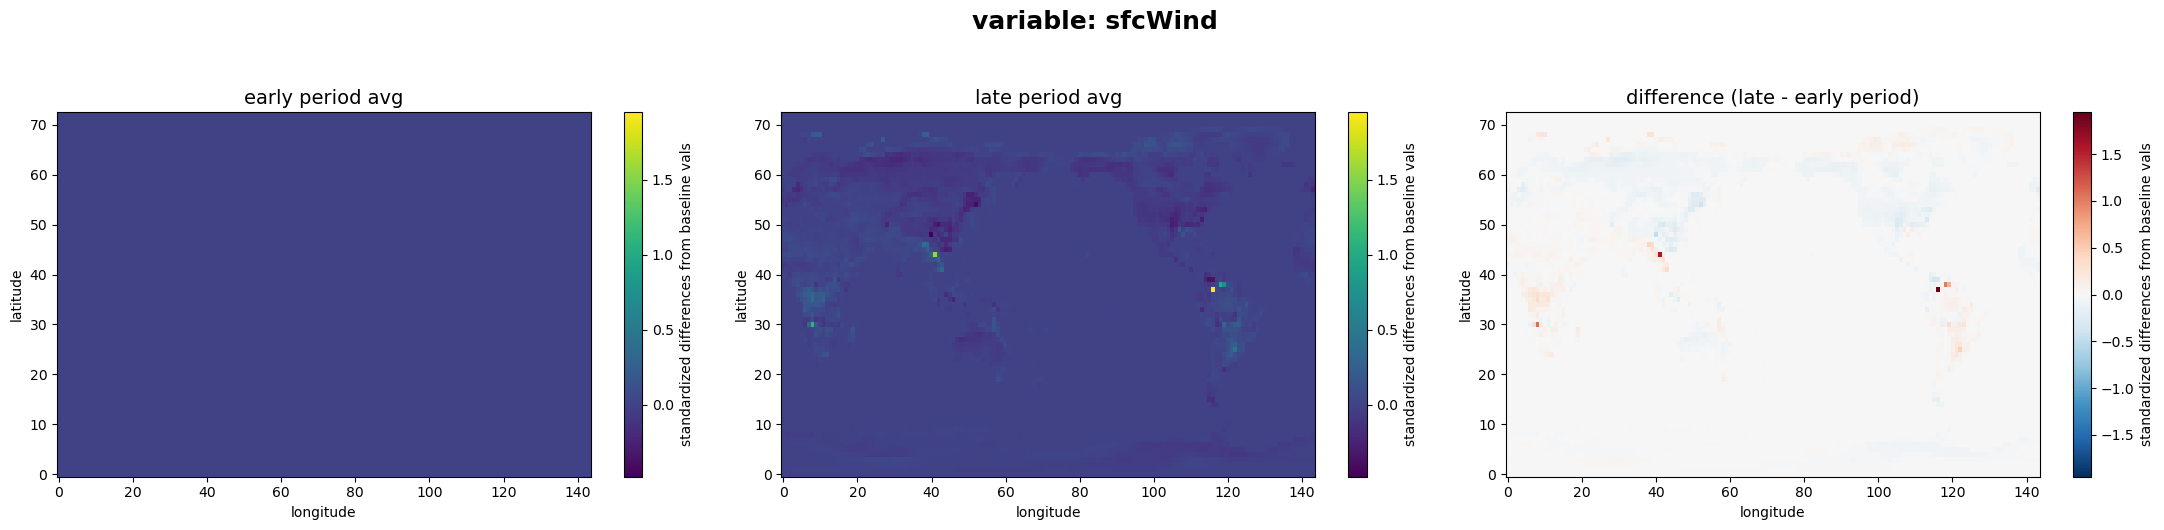

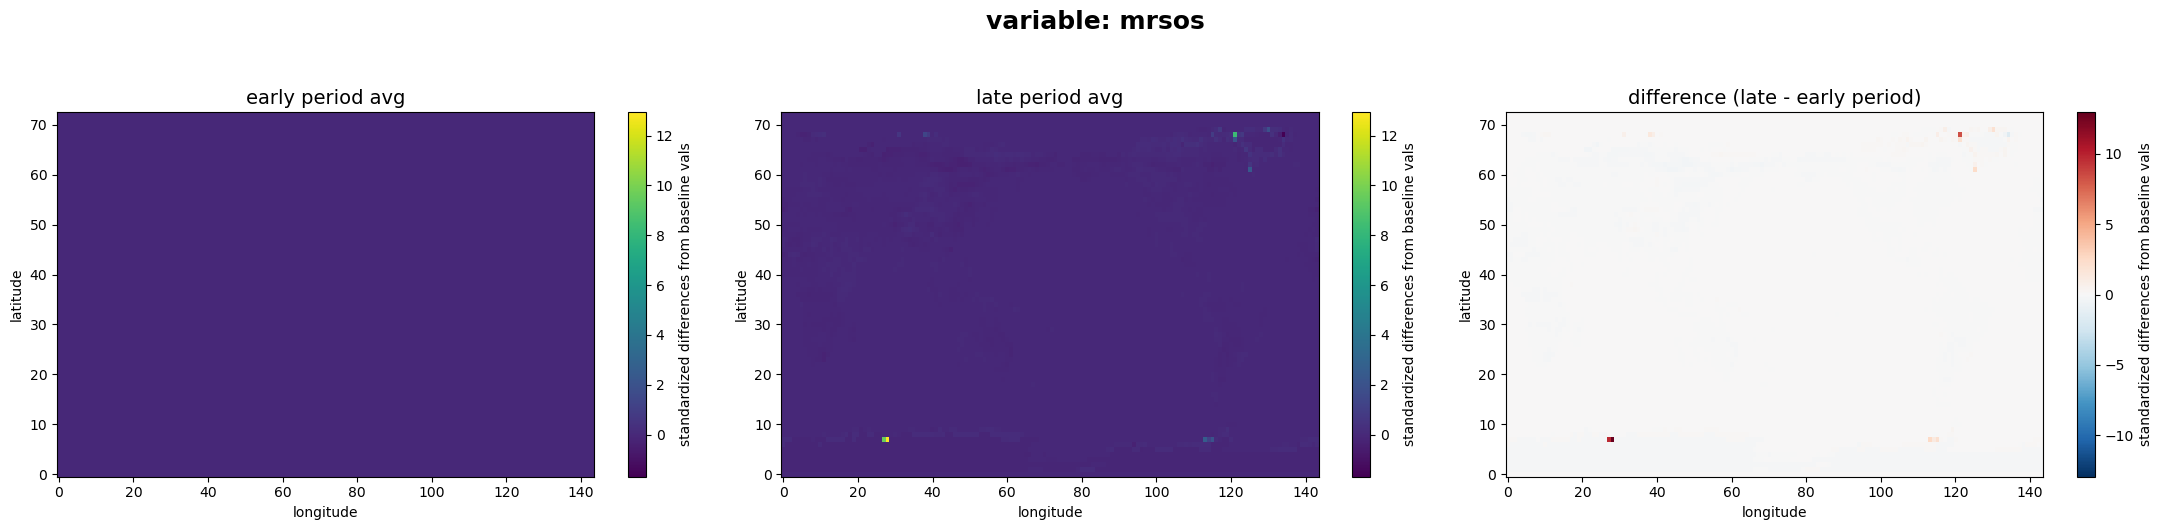

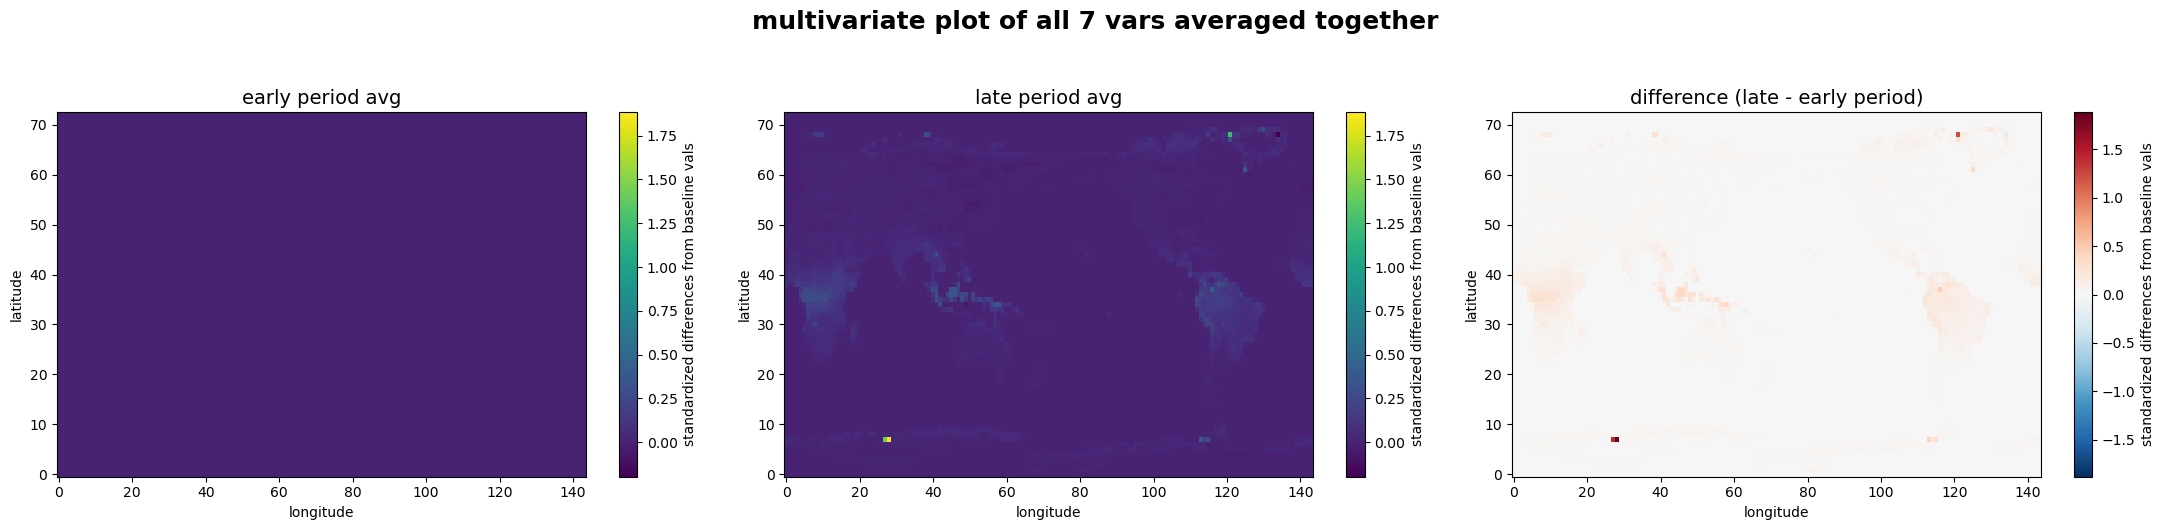

processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_7198/3003169814.py:93: RuntimeWarning: Mean of empty slice
  p_mean = np.nanmean(baseline_slice, axis=(0, 2))
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_7198/3003169814.py:117: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL


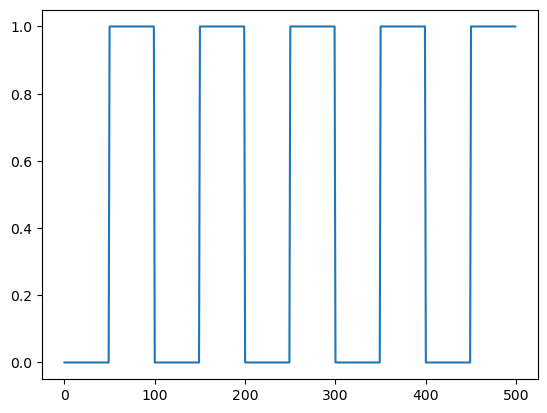

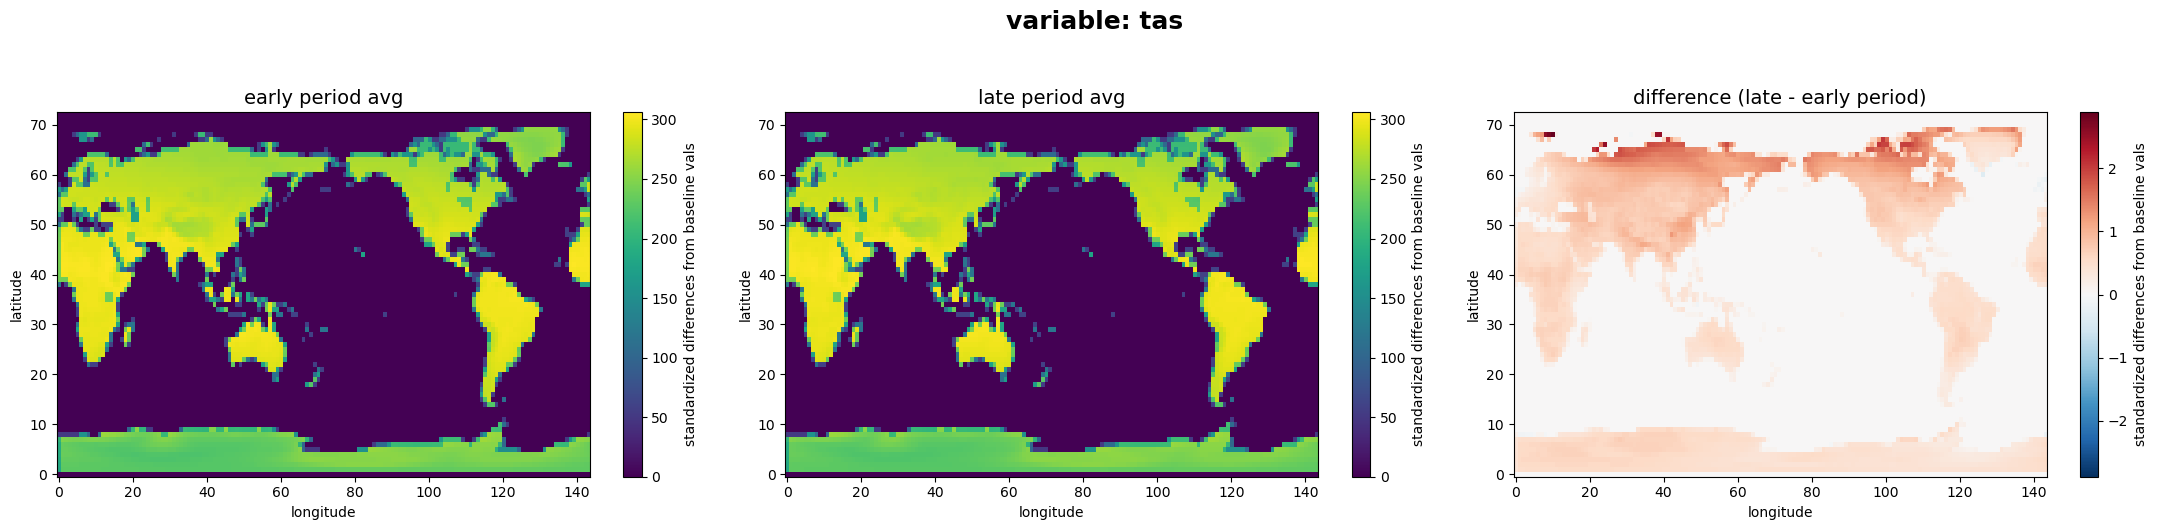

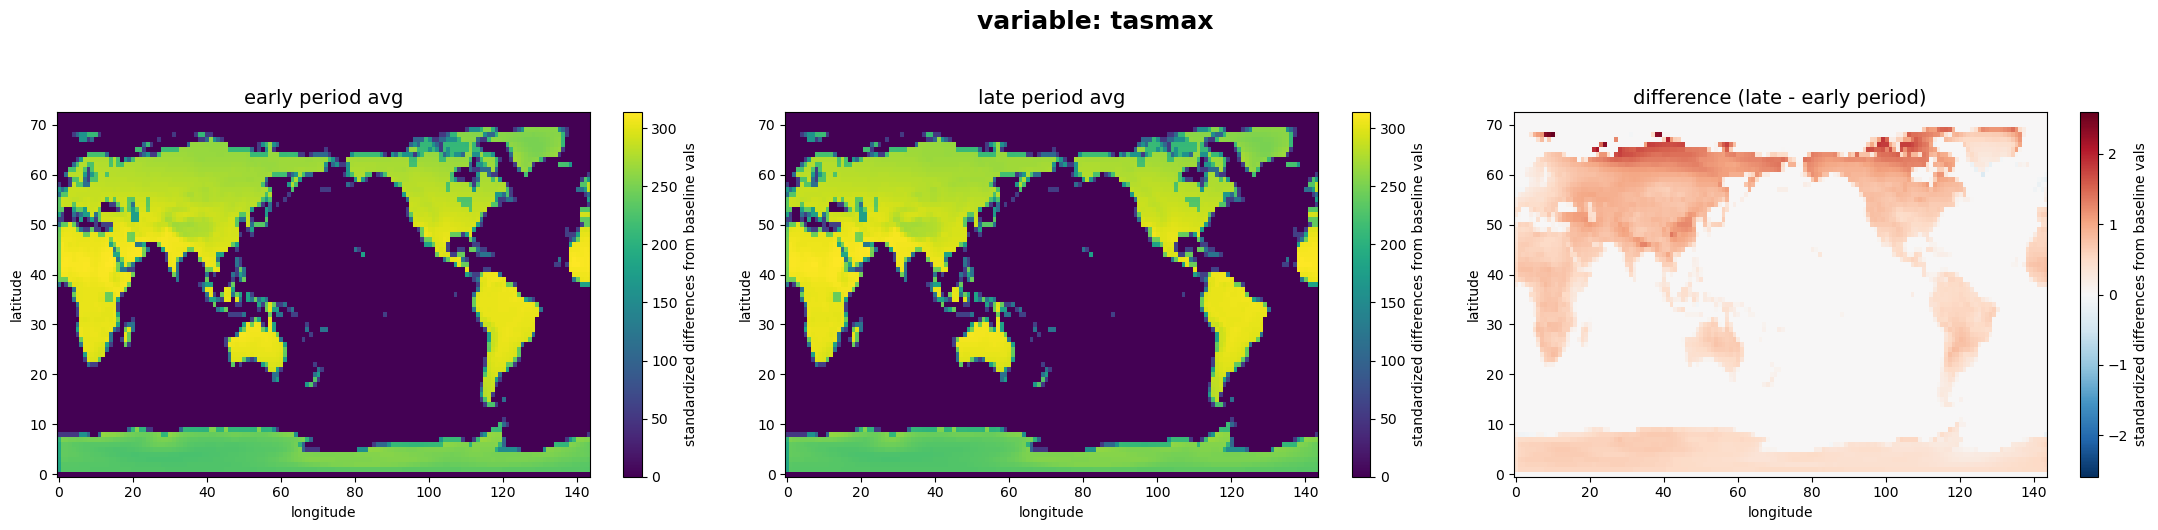

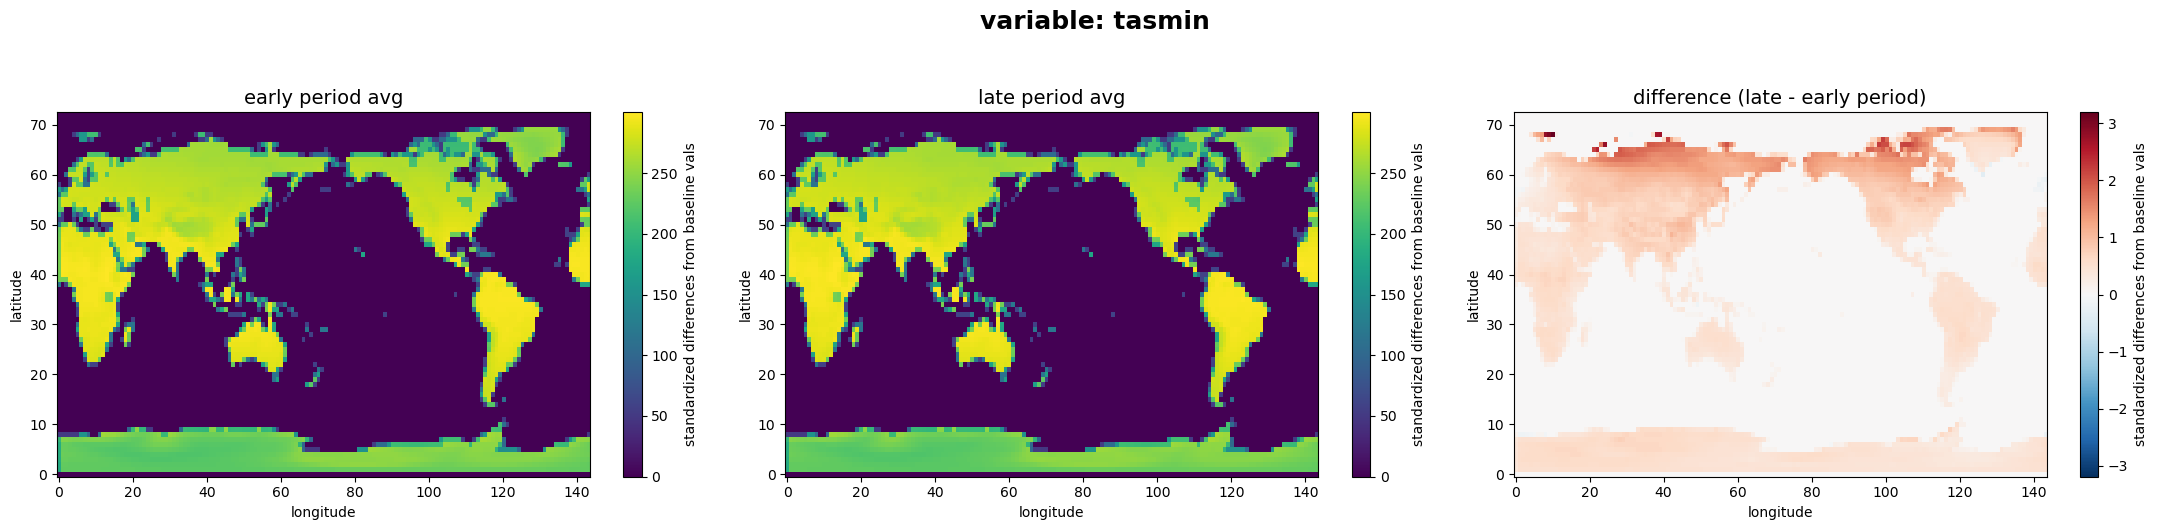

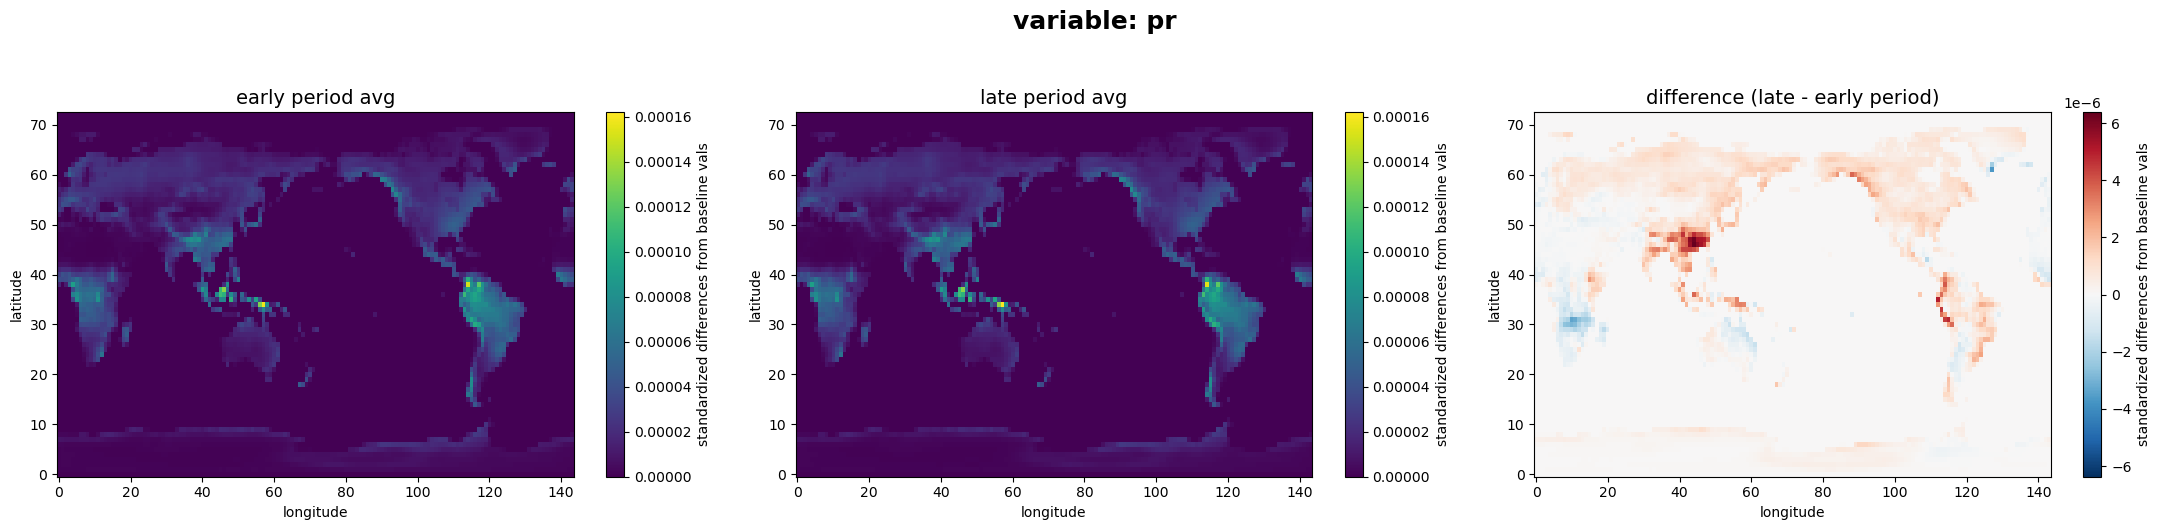

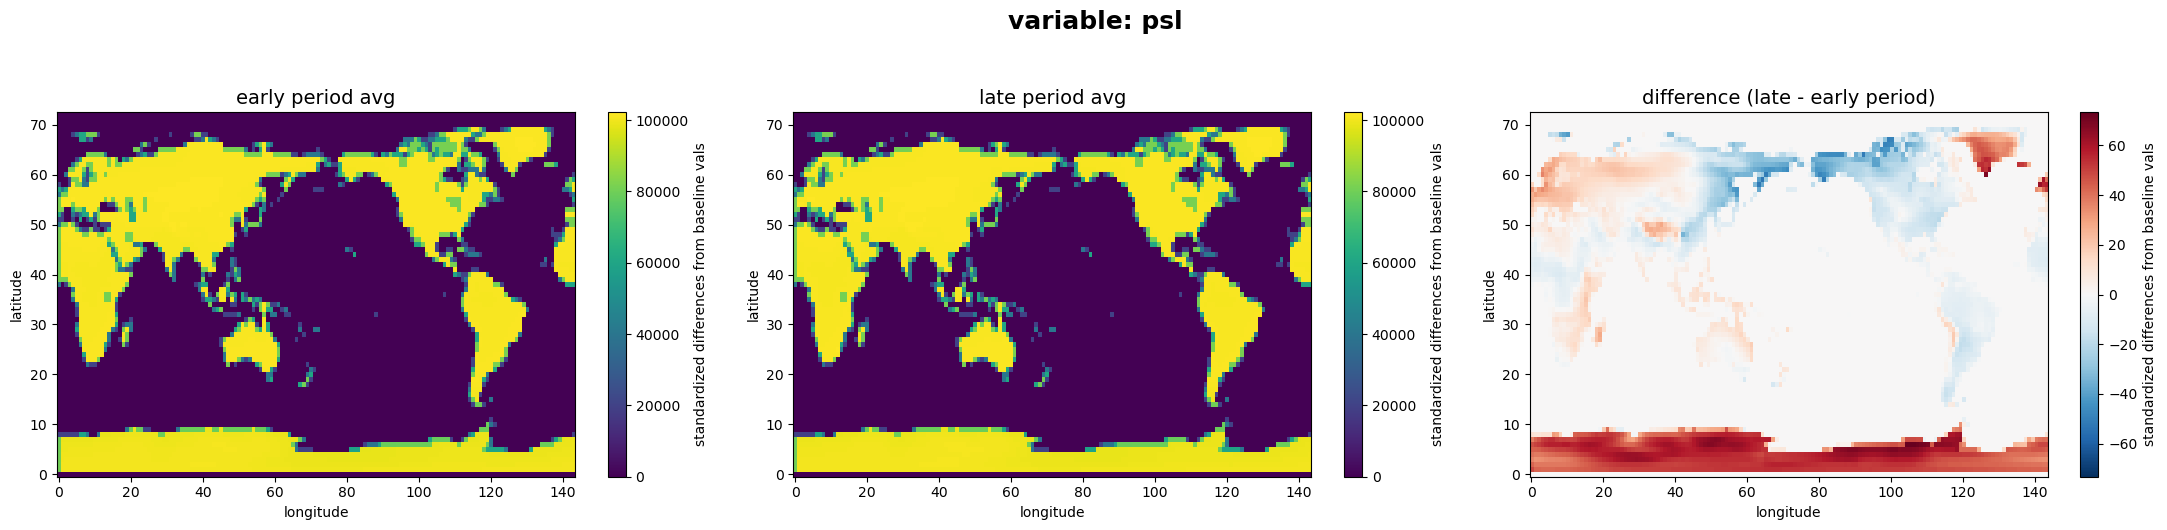

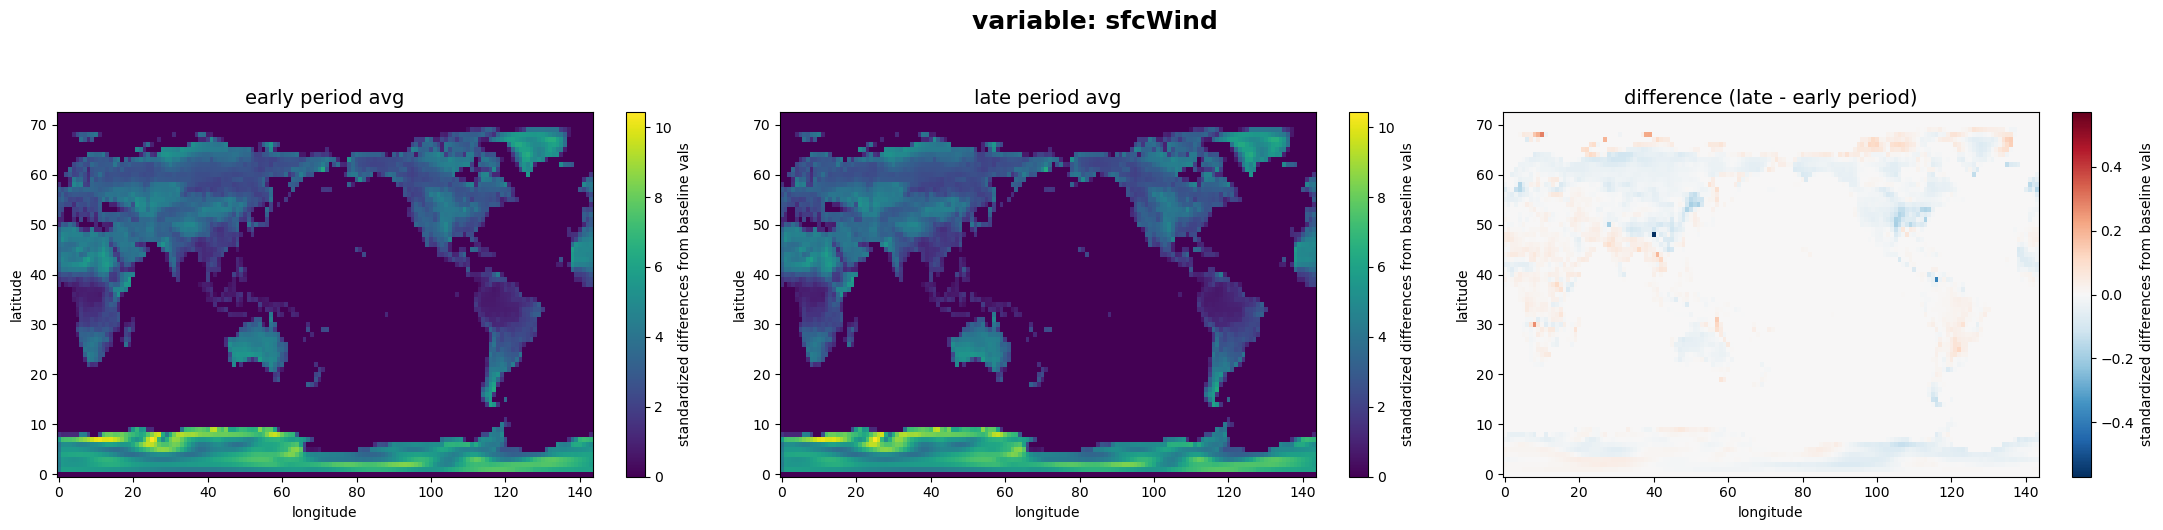

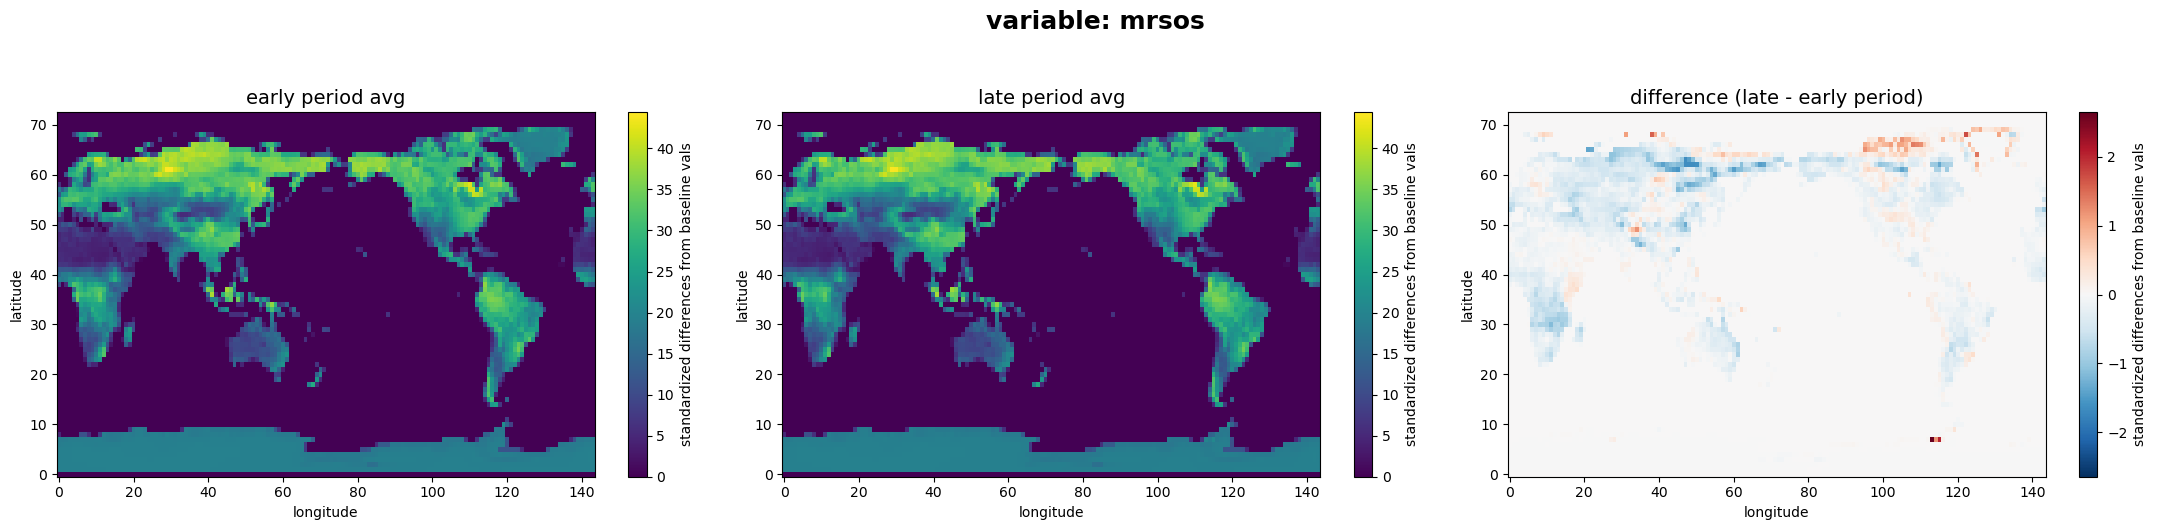

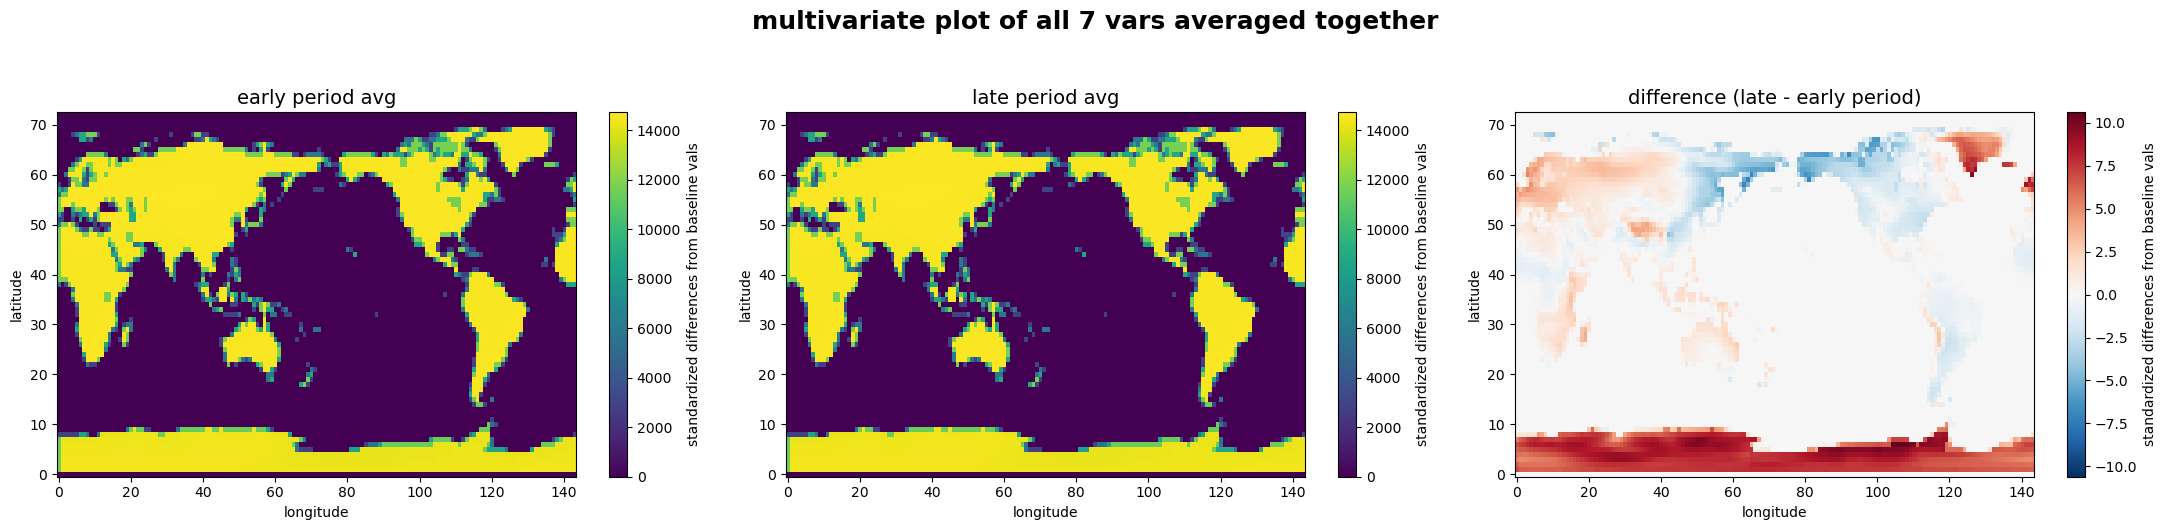

In [7]:
%run "/Users/sophiekim/Desktop/2_research/get_cnn_data_v3_sk.ipynb"

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models


In [9]:
x_data, y_data = get_cnn_tensors(
    model_list=model_list,
    scenario="ssp126",
    data_path=data_path,         
    use_anomaly=True,  
    stat="mean",
    st_early=2015, end_early=2024,
    st_late=2055, end_late=2064
)

print(x_data.shape, y_data.shape)


processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_7198/3003169814.py:93: RuntimeWarning: Mean of empty slice
  p_mean = np.nanmean(baseline_slice, axis=(0, 2))
/Users/sophiekim/miniforge3/envs/climate_env/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_7198/3003169814.py:117: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
(500, 7, 144, 73) (500, 1)


In [10]:
x_data

array([[[[ 0.00000000e+00,  9.39362685e-03, -5.03828109e-02, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  9.39362685e-03, -5.03828109e-02, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  8.19527128e-03, -6.29179070e-02, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         ...,
         [ 0.00000000e+00,  6.37170262e-04, -3.58110286e-02, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  8.46388197e-03, -3.75099031e-02, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  9.39362685e-03, -5.03828109e-02, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

        [[ 0.00000000e+00,  2.45002869e-02, -4.68739487e-02, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  2.45002869e-02, -4.68739487e-02, ...,
           0.00000000e

In [11]:
X = np.transpose(x_data, (0, 2, 3, 1))  # (N, lat, lon, 1)
y = y_data.astype(np.float32)           # (N, 1)

print("X:", X.shape, "y:", y.shape) # FIX 2: SHOULD BE (500,144,73,7) and (500,1)

X: (500, 144, 73, 7) y: (500, 1)


Reason for transposing: From get_cnn_tensors, my raw tensor shape was (1000, 1, 144, 73). This means 1000 samples, 1 channel, 144 latitude, 73 longitude. However, TensorFlow expects (1000 ,144, 73, 1) format. This is ensuring that my CNN sees [lat,lon] as the 2D image. 

In [12]:
# 1) test = 50
X_rem, X_test, y_rem, y_test = train_test_split(
    X, y,
    test_size=50,
    random_state=42,
    stratify=y
)

# 2) val = 50 (from remaining 450)
X_train, X_val, y_train, y_val = train_test_split(
    X_rem, y_rem,
    test_size=50,
    random_state=42,
    stratify=y_rem
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Class balance:", y_train.mean(), y_val.mean(), y_test.mean())


Train: (400, 144, 73, 7) Val: (50, 144, 73, 7) Test: (50, 144, 73, 7)
Class balance: 0.5 0.5 0.5


In [13]:
def nan_report(name, arr):
    frac = np.isnan(arr).mean()
    print(f"{name}: any NaNs? {np.isnan(arr).any()} | frac NaNs = {frac:.6f}")

nan_report("X_train", X_train)
nan_report("X_val", X_val)
nan_report("X_test", X_test)


X_train: any NaNs? False | frac NaNs = 0.000000
X_val: any NaNs? False | frac NaNs = 0.000000
X_test: any NaNs? False | frac NaNs = 0.000000


## Medium Architecture (~92k parameters)

In [14]:
lat, lon = X_train.shape[1], X_train.shape[2]

model = models.Sequential([
    layers.Input(shape=(lat, lon, 7)), # FIX #1: SHOULD BE A 7 (lat,lon,7)

    # CNN block (64 filters) with two convs, then pool
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),  # (lat/2, lon/2, 64)

    # CNN block 32 kernels (conv + pool)
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),  # (lat/4, lon/4, 32) 

    # CNN block 16 kernels (conv only)
    layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(8, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(8, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),             
    layers.Dense(50, activation="relu"),
    layers.Dense(10, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.summary()


2026-03-07 12:21:37.770731: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-07 12:21:37.771088: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-07 12:21:37.771287: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-07 12:21:37.771466: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-07 12:21:37.771478: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 144, 73, 64)    │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 144, 73, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 72, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 72, 36, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 72, 36, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 36, 18, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 36, 18, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 9, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 18, 9, 8)       │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 18, 9, 8)       │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │        14,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,395 (360.92 KB)

 Trainable params: 92,395 (360.92 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=2
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=18,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100


2026-03-07 12:21:38.623151: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.6850 - loss: 0.6801 - val_accuracy: 0.8200 - val_loss: 0.6748
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.8025 - loss: 0.6641 - val_accuracy: 0.8400 - val_loss: 0.6521
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.8200 - loss: 0.6178 - val_accuracy: 0.8200 - val_loss: 0.5639
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.8375 - loss: 0.4645 - val_accuracy: 0.9000 - val_loss: 0.3345
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.9025 - loss: 0.2894 - val_accuracy: 0.9200 - val_loss: 0.2104
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.9075 - loss: 0.2241 - val_accuracy: 0.9600 - val_loss: 0.1441
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.9375 - loss: 0.1568 - val_accuracy: 0.9800 - val_loss: 0.1071
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.9475 - loss: 0.1191 - val_accuracy: 0.9400 - val_l

In [16]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test accuracy:", test_acc)

Test accuracy: 0.9599999785423279


In [17]:
#.............................................
# SAVE THE TRAINED NETWORK
#.............................................

model.save('my_medium_cnn.keras') # or can do .h5 

In [18]:
model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


array([[9.8116260e-10],
       [9.9899238e-01],
       [4.0563282e-11],
       [9.9988806e-01],
       [2.0935668e-14],
       [2.7604322e-10],
       [4.3614791e-03],
       [3.2682876e-09],
       [1.2736596e-10],
       [1.0000000e+00],
       [1.0000000e+00],
       [9.9999988e-01],
       [1.3818892e-12],
       [3.5378360e-08],
       [2.5209684e-10],
       [2.3908905e-07],
       [2.9536391e-08],
       [1.5551369e-13],
       [1.7332021e-11],
       [9.9999964e-01],
       [9.9995065e-01],
       [1.0000000e+00],
       [2.5623479e-01],
       [9.9998569e-01],
       [1.0000000e+00],
       [9.9643302e-01],
       [8.1180166e-05],
       [1.0000000e+00],
       [2.1391522e-09],
       [1.0000000e+00],
       [9.9999988e-01],
       [9.8579180e-01],
       [4.0122374e-11],
       [3.1845537e-03],
       [1.0000000e+00],
       [9.9947459e-01],
       [8.9549339e-01],
       [9.7918987e-01],
       [1.0000000e+00],
       [9.4699234e-01],
       [1.5272795e-16],
       [2.815167

In [19]:
y_test

array([[0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.]], dtype=float32)

In [20]:
# giving model an input of all zeroes to see what it would predict if everything was 0 -- like a baseline situation
model.predict(X_test[0:1]*0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


array([[0.0106508]], dtype=float32)

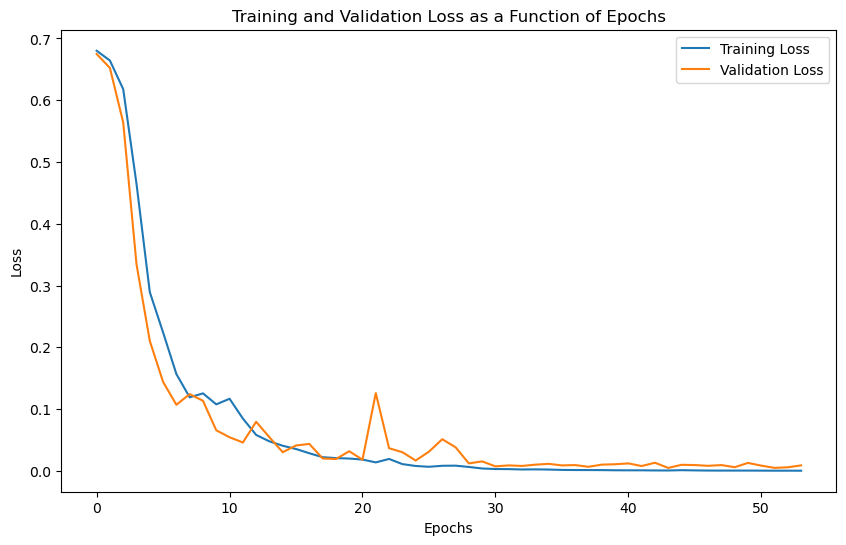

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss as a Function of Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


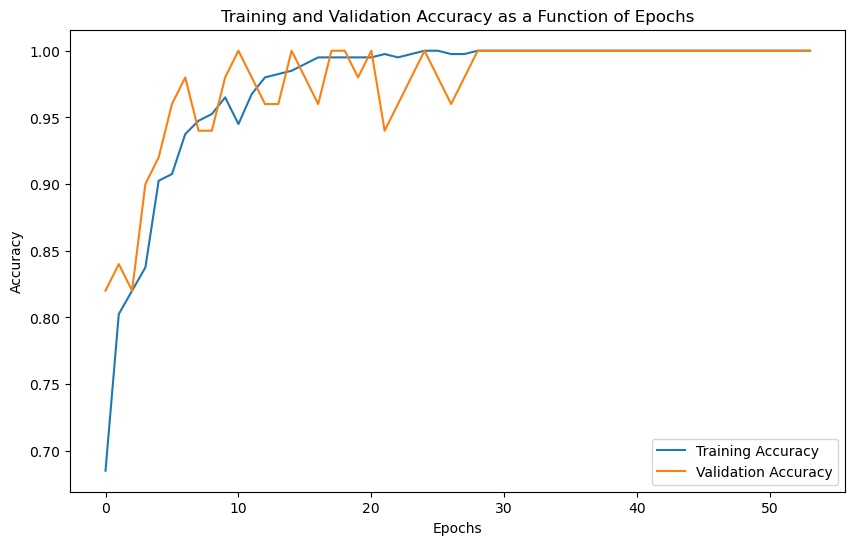

In [22]:
plt.figure(figsize=(10,6))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy as a Function of Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


## **XAI**

In [23]:
def get_gradients(inputs, model, top_pred_idx=None):
    """Computes the gradients of outputs w.r.t input image.

    Args:
        inputs: 2D/3D/4D matrix of samples
        top_pred_idx: (optional) Predicted label for the x_data
                      if classification problem. If regression,
                      do not include.

    Returns:
        Gradients of the predictions w.r.t img_input
    """
    inputs = tf.cast(inputs, tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(inputs)
        
        # Run the forward pass of the layer and record operations
        # on GradientTape.
        preds = model(inputs, training=False)  
        
        # For classification, grab the top class
        if top_pred_idx is not None:
            preds = preds[:, top_pred_idx]
        
    # Use the gradient tape to automatically retrieve
    # the gradients of the trainable variables with respect to the loss.        
    grads = tape.gradient(preds, inputs)
    return grads

def get_integrated_gradients(inputs, model, baseline=None, num_steps=50, top_pred_idx=None):
    """Computes Integrated Gradients for a prediction.

    Args:
        inputs (ndarray): 2D/3D/4D matrix of samples
        baseline (ndarray): The baseline image to start with for interpolation
        num_steps: Number of interpolation steps between the baseline
            and the input used in the computation of integrated gradients. These
            steps along determine the integral approximation error. By default,
            num_steps is set to 50.
        top_pred_idx: (optional) Predicted label for the x_data
                      if classification problem. If regression,
                      do not include.            

    Returns:
        Integrated gradients w.r.t input image
    """
    # If baseline is not provided, start with zeros
    # having same size as the input image.
    if baseline is None:
        input_size = np.shape(inputs)[1:]
        baseline = np.zeros(input_size).astype(np.float32)
    else:
        baseline = baseline.astype(np.float32)

    # 1. Do interpolation.
    inputs = inputs.astype(np.float32)
    interpolated_inputs = [
        baseline + (step / num_steps) * (inputs - baseline)
        for step in range(num_steps + 1)
    ]
    interpolated_inputs = np.array(interpolated_inputs).astype(np.float32)

    # 3. Get the gradients
    grads = []
    for i, x_data in enumerate(interpolated_inputs):
        grad = get_gradients(x_data, model, top_pred_idx=top_pred_idx)     
        grads.append(grad)
    grads = tf.convert_to_tensor(grads, dtype=tf.float32)

    # 4. Approximate the integral using the trapezoidal rule
    grads = (grads[:-1] + grads[1:]) / 2.0
    avg_grads = tf.reduce_mean(grads, axis=0)
    # 5. Calculate integrated gradients and return
    integrated_grads = (inputs - baseline) * avg_grads
    return integrated_grads

def random_baseline_integrated_gradients(inputs, num_steps=50, num_runs=5, top_pred_idx=None):
    """Generates a number of random baseline images.

    Args:
        inputs (ndarray): 2D/3D/4D matrix of samples
        num_steps: Number of interpolation steps between the baseline
            and the input used in the computation of integrated gradients. These
            steps along determine the integral approximation error. By default,
            num_steps is set to 50.
        num_runs: number of baseline images to generate
        top_pred_idx: (optional) Predicted label for the x_data
                      if classification problem. If regression,
                      do not include.      

    Returns:
        Averaged integrated gradients for `num_runs` baseline images
    """
    # 1. List to keep track of Integrated Gradients (IG) for all the images
    integrated_grads = []

    # 2. Get the integrated gradients for all the baselines
    for run in range(num_runs):
        baseline = np.zeros(np.shape(inputs)[1:])
        for i in np.arange(0,np.shape(baseline)[0]):
            j = np.random.choice(np.arange(0,np.shape(inputs)[0]))
            baseline[i] = inputs[j,i]

        igrads = get_integrated_gradients(
            inputs=inputs,
            baseline=baseline,
            num_steps=num_steps,
            top_pred_idx=top_pred_idx)
        integrated_grads.append(igrads)

    # 3. Return the average integrated gradients for the image
    integrated_grads = tf.convert_to_tensor(integrated_grads)
    return tf.reduce_mean(integrated_grads, axis=0)



In [24]:
sample = 3
IntegratedGrad_zeros_heatmap=get_integrated_gradients(X_test[sample:sample+1],model).numpy()

## ***importing stuff (was having trouble before)***

In [25]:
import sys
# This ensures we use the exact same Python path as your notebook
!{sys.executable} -m pip install --no-cache-dir pyproj cartopy "shapely<2.0"

✅ SUCCESS!
PyProj: 3.7.1
Shapely: 1.8.5.post1


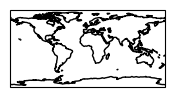

🌍 Map rendered! You are ready to plot.


In [26]:
try:
    import pyproj
    import cartopy.crs as ccrs
    import shapely
    print(f"✅ SUCCESS!")
    print(f"PyProj: {pyproj.__version__}")
    print(f"Shapely: {shapely.__version__}")
    
    # The ultimate test: can it handle a projection?
    import matplotlib.pyplot as plt
    fig = plt.figure(figsize=(2, 2))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()
    plt.show()
    print("🌍 Map rendered! You are ready to plot.")
except Exception as e:
    print(f"❌ Still missing a piece: {e}")

## **PLOTS**

In [27]:
# Plotting figures
import matplotlib.pyplot as plt #Main plotting package
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import cartopy.mpl.ticker as cticker

In [28]:

# Get lat and lon from opening any ds
file_path = data_path + '/CNRM_ESM2-1_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc'
ds = nc.Dataset(file_path)
lat = np.array(ds["lat"][:]) # extracting latitude and longitude grids
lon = np.array(ds["lon"][:])

In [29]:
X_test = np.transpose(X_test,(0,2,1,3))
IntegratedGrad_zeros_heatmap = np.transpose(IntegratedGrad_zeros_heatmap,(0,2,1,3))
variable = 1

### **TAS**

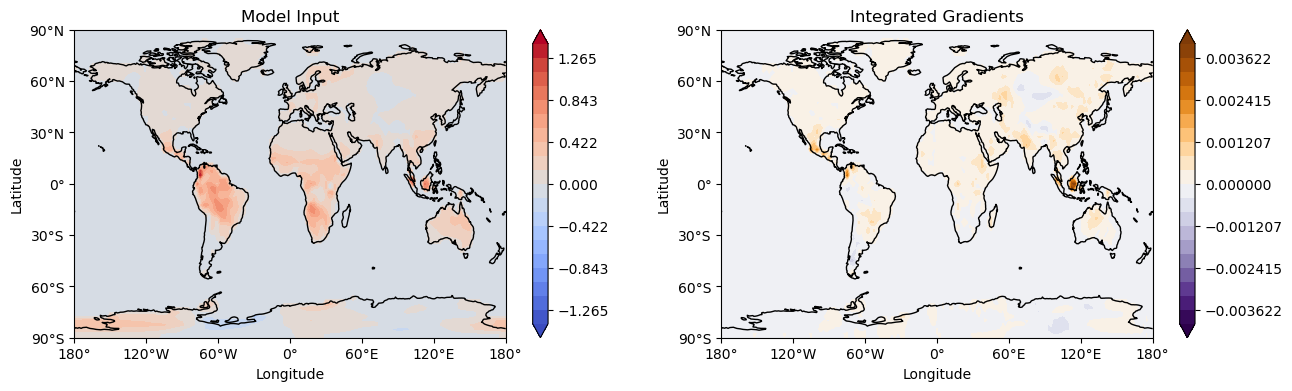

In [34]:
plt.figure(figsize=(32,4))
ax=plt.subplot(1,4,1,projection=ccrs.PlateCarree())
samplep,lonp = add_cyclic_point(X_test[sample,:,:,variable], coord=lon)
cs = plt.contourf(lonp, lat, samplep, cmap ="coolwarm",levels = np.linspace(-np.max(np.abs(X_test[sample,:,:,variable]),axis=(0,1)),np.max(np.abs(X_test[sample,:,:,variable]),axis=(0,1)),21),extend = 'both')  
cbar = plt.colorbar(cs)   
plt.title('Model Input') 
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.axis('tight')
ax.coastlines()
#plt.legend()
# Define the xticks for longitude
ax.set_xticks(np.arange(-180,181,60), crs=ccrs.PlateCarree())
lon_formatter = cticker.LongitudeFormatter()
ax.xaxis.set_major_formatter(lon_formatter)
# Define the yticks for latitude
ax.set_yticks(np.arange(-90,91,30), crs=ccrs.PlateCarree())
lat_formatter = cticker.LatitudeFormatter()
ax.yaxis.set_major_formatter(lat_formatter)

ax=plt.subplot(1,4,2,projection=ccrs.PlateCarree())
samplep,lonp = add_cyclic_point(IntegratedGrad_zeros_heatmap[0,:,:,variable], coord=lon)
cs = plt.contourf(lonp, lat, samplep, cmap ="PuOr_r",levels = np.linspace(-np.max(np.abs(IntegratedGrad_zeros_heatmap[0,:,:,variable]),axis=(0,1)),np.max(np.abs(IntegratedGrad_zeros_heatmap[0,:,:,variable]),axis=(0,1)),21),extend = 'both')  
cbar = plt.colorbar(cs)   
plt.title('Integrated Gradients') 
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.axis('tight')
ax.coastlines()
#plt.legend()
# Define the xticks for longitude
ax.set_xticks(np.arange(-180,181,60), crs=ccrs.PlateCarree())
lon_formatter = cticker.LongitudeFormatter()
ax.xaxis.set_major_formatter(lon_formatter)
# Define the yticks for latitude
ax.set_yticks(np.arange(-90,91,30), crs=ccrs.PlateCarree())
lat_formatter = cticker.LatitudeFormatter()
ax.yaxis.set_major_formatter(lat_formatter)
plt.show()

### **ALL VARS**

In [ ]:
var_list = ["tas", "tasmax", "tasmin", "pr", "psl", "sfcWind", "mrsos"]

for i in range(len(var_list)):
        # 1. Isolate the data
        data_slice = X_test[sample, :, :, i]
        
        # 2. Add cyclic point to prevent the white gap at the prime meridian
        samplep, lonp = add_cyclic_point(data_slice, coord=lon)
        plt.figure(figsize=(32,4))
        ax=plt.subplot(1,4,1,projection=ccrs.PlateCarree())
        cs = plt.contourf(lonp, lat, samplep, cmap ="coolwarm",levels = np.linspace(-np.max(np.abs(X_test[sample,:,:,variable]),axis=(0,1)),np.max(np.abs(X_test[sample,:,:,variable]),axis=(0,1)),21),extend = 'both')  
        cbar = plt.colorbar(cs)   
        plt.title(f'Model Input for {var_list[i]}') 
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.axis('tight')
        ax.coastlines()
        #plt.legend()
        # Define the xticks for longitude
        ax.set_xticks(np.arange(-180,181,60), crs=ccrs.PlateCarree())
        lon_formatter = cticker.LongitudeFormatter()
        ax.xaxis.set_major_formatter(lon_formatter)
        # Define the yticks for latitude
        ax.set_yticks(np.arange(-90,91,30), crs=ccrs.PlateCarree())
        lat_formatter = cticker.LatitudeFormatter()
        ax.yaxis.set_major_formatter(lat_formatter)

        ax=plt.subplot(1,4,2,projection=ccrs.PlateCarree())
        samplep,lonp = add_cyclic_point(IntegratedGrad_zeros_heatmap[0,:,:,variable], coord=lon)
        cs = plt.contourf(lonp, lat, samplep, cmap ="PuOr_r",levels = np.linspace(-np.max(np.abs(IntegratedGrad_zeros_heatmap[0,:,:,variable]),axis=(0,1)),np.max(np.abs(IntegratedGrad_zeros_heatmap[0,:,:,variable]),axis=(0,1)),21),extend = 'both')  
        cbar = plt.colorbar(cs)   
        plt.title(f'Integrated Gradients for {var_list[i]}') 
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.axis('tight')
        ax.coastlines()
        #plt.legend()
        # Define the xticks for longitude
        ax.set_xticks(np.arange(-180,181,60), crs=ccrs.PlateCarree())
        lon_formatter = cticker.LongitudeFormatter()
        ax.xaxis.set_major_formatter(lon_formatter)
        # Define the yticks for latitude
        ax.set_yticks(np.arange(-90,91,30), crs=ccrs.PlateCarree())
        lat_formatter = cticker.LatitudeFormatter()
        ax.yaxis.set_major_formatter(lat_formatter)
        plt.show()
            

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
--- Analysis for Sample #5 ---
Ground Truth: 0.0000
Prediction:   0.0052
Difference:   0.0052
-----------------------------------


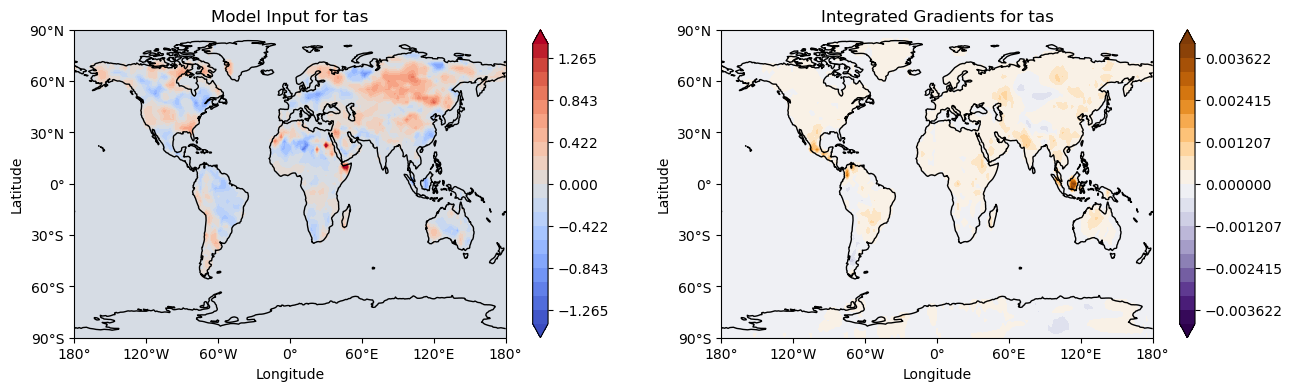

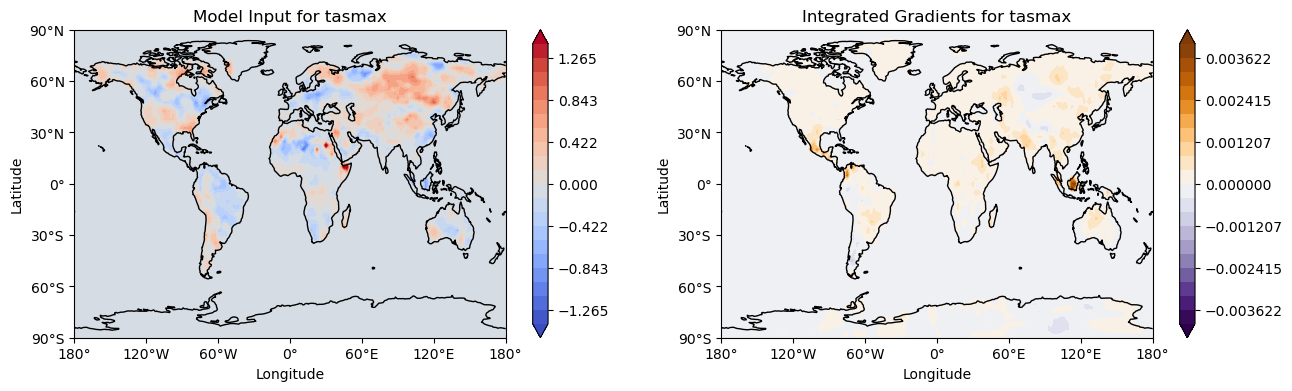

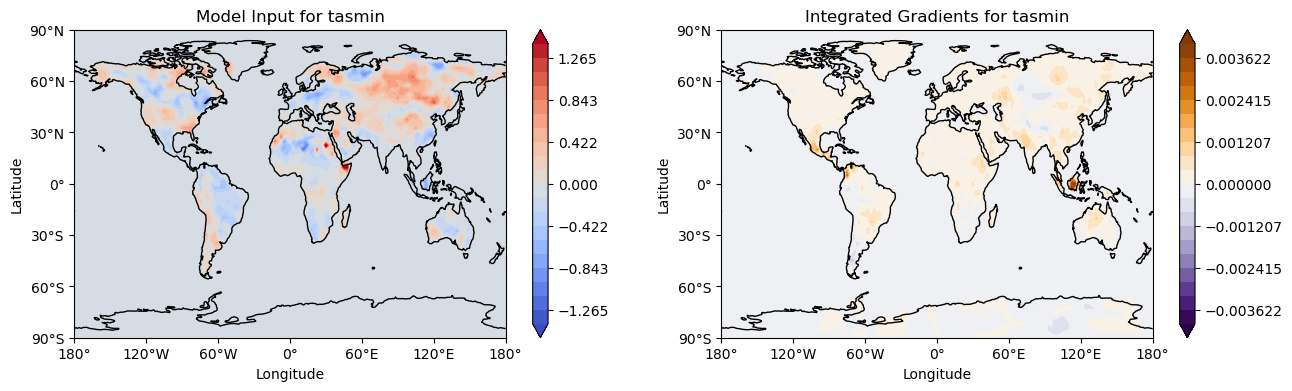

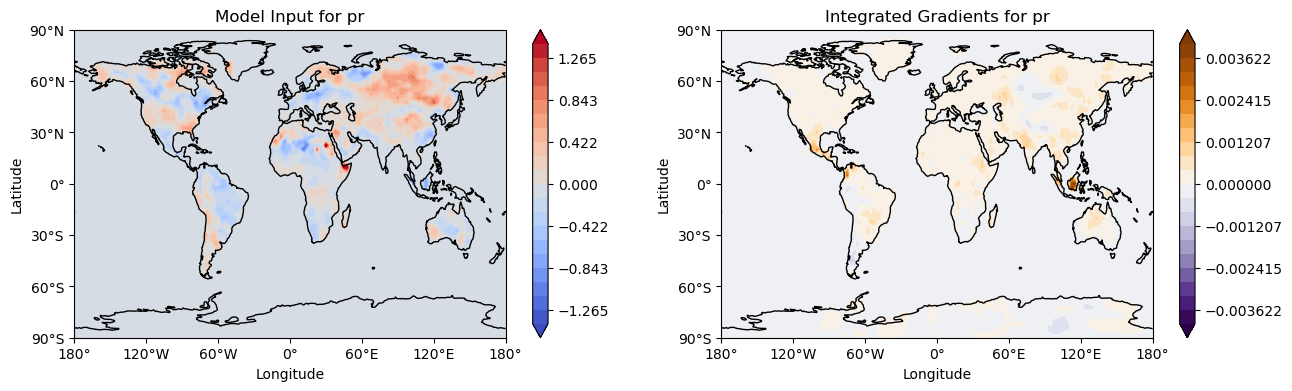

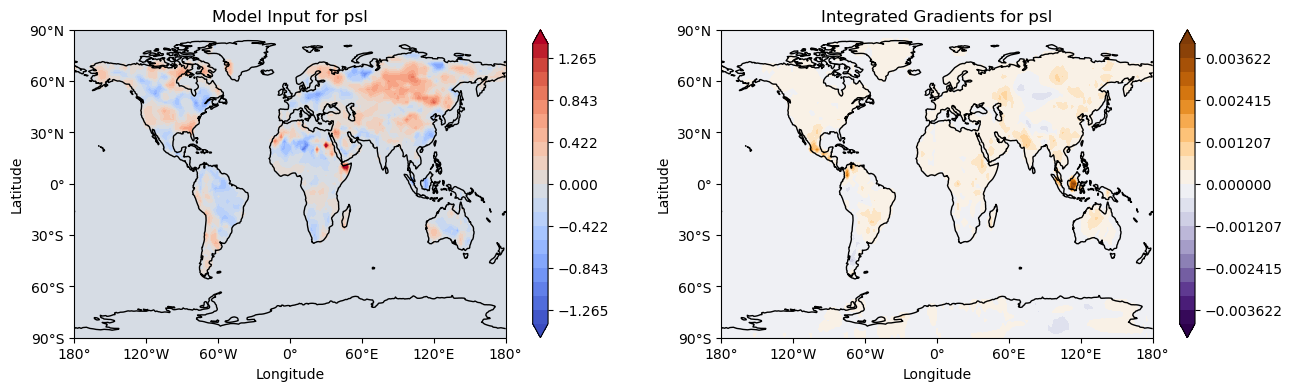

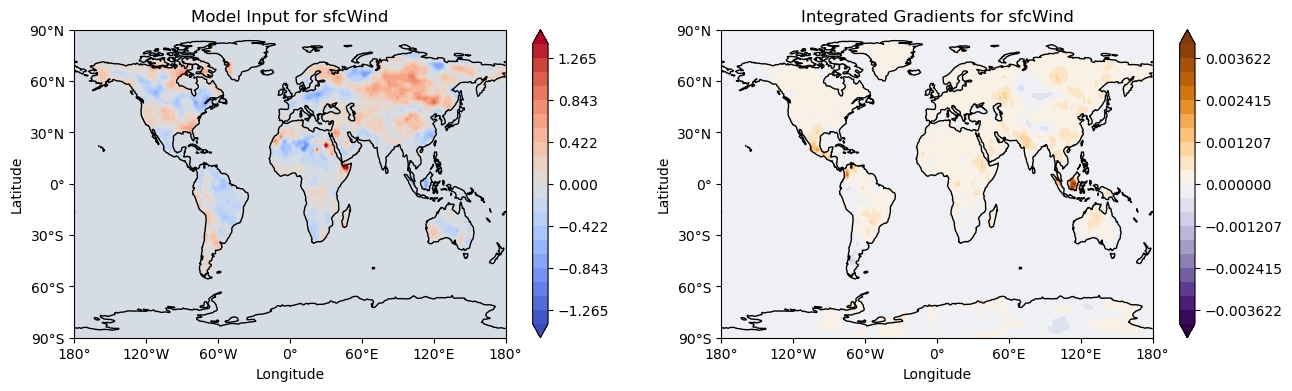

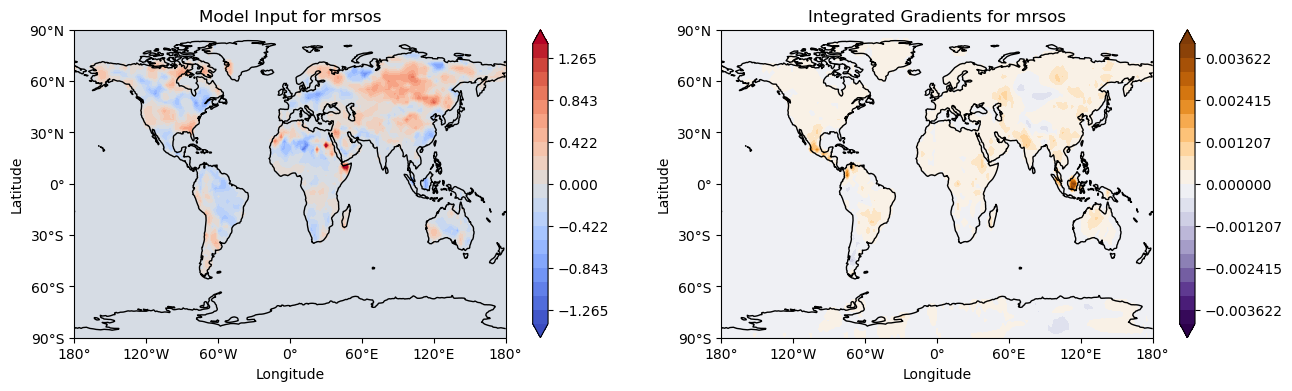

In [40]:
def explain_pred(sample_idx):
    # 1. Get Prediction and Ground Truth
    # We use [sample_idx:sample_idx+1] to keep the 4D shape (1, lat, lon, 7)
    y_pred = model.predict(X_test[sample_idx:sample_idx+1])[0][0]
    y_true = y_test[sample_idx].item()
    
    print(f"--- Analysis for Sample #{sample_idx} ---")
    print(f"Ground Truth: {y_true:.4f}")
    print(f"Prediction:   {y_pred:.4f}")
    print(f"Difference:   {abs(y_true - y_pred):.4f}")
    print("-" * 35)

    # 2. Loop through each of the 7 variables
    for i in range(len(var_list)):
        # 2. Add cyclic point to prevent the white gap at the prime meridian
        samplep, lonp = add_cyclic_point(data_slice, coord=lon)
        plt.figure(figsize=(32,4))
        ax=plt.subplot(1,4,1,projection=ccrs.PlateCarree())
        cs = plt.contourf(lonp, lat, samplep, cmap ="coolwarm",levels = np.linspace(-np.max(np.abs(X_test[sample,:,:,variable]),axis=(0,1)),np.max(np.abs(X_test[sample,:,:,variable]),axis=(0,1)),21),extend = 'both')  
        cbar = plt.colorbar(cs)   
        plt.title(f'Model Input for {var_list[i]}') 
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.axis('tight')
        ax.coastlines()
        #plt.legend()
        # Define the xticks for longitude
        ax.set_xticks(np.arange(-180,181,60), crs=ccrs.PlateCarree())
        lon_formatter = cticker.LongitudeFormatter()
        ax.xaxis.set_major_formatter(lon_formatter)
        # Define the yticks for latitude
        ax.set_yticks(np.arange(-90,91,30), crs=ccrs.PlateCarree())
        lat_formatter = cticker.LatitudeFormatter()
        ax.yaxis.set_major_formatter(lat_formatter)

        ax=plt.subplot(1,4,2,projection=ccrs.PlateCarree())
        samplep,lonp = add_cyclic_point(IntegratedGrad_zeros_heatmap[0,:,:,variable], coord=lon)
        cs = plt.contourf(lonp, lat, samplep, cmap ="PuOr_r",levels = np.linspace(-np.max(np.abs(IntegratedGrad_zeros_heatmap[0,:,:,variable]),axis=(0,1)),np.max(np.abs(IntegratedGrad_zeros_heatmap[0,:,:,variable]),axis=(0,1)),21),extend = 'both')  
        cbar = plt.colorbar(cs)   
        plt.title(f'Integrated Gradients for {var_list[i]}') 
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.axis('tight')
        ax.coastlines()
        #plt.legend()
        # Define the xticks for longitude
        ax.set_xticks(np.arange(-180,181,60), crs=ccrs.PlateCarree())
        lon_formatter = cticker.LongitudeFormatter()
        ax.xaxis.set_major_formatter(lon_formatter)
        # Define the yticks for latitude
        ax.set_yticks(np.arange(-90,91,30), crs=ccrs.PlateCarree())
        lat_formatter = cticker.LatitudeFormatter()
        ax.yaxis.set_major_formatter(lat_formatter)
        plt.show()

# Run it for sample 5
explain_pred(5)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


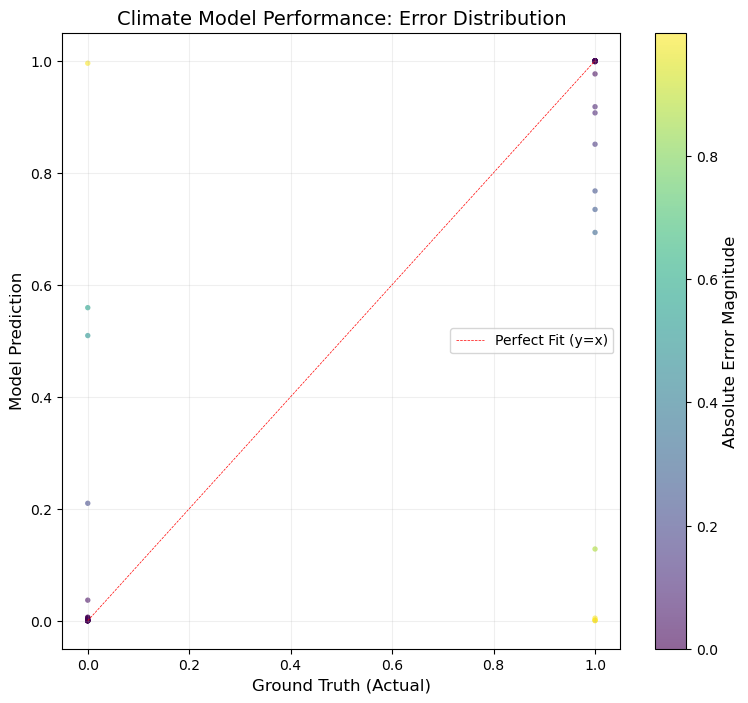

In [43]:
def plot_overall_performance():
    # 1. Get all predictions and truths as flat arrays
    all_preds = model.predict(X_test).flatten()
    all_truth = y_test.flatten()
    
    # 2. Calculate the absolute error for each point to use as a color map
    errors = np.abs(all_preds - all_truth)
    
    plt.figure(figsize=(9, 8))
    
    # 3. Create the scatter plot with a colormap (cmap)
    # 'viridis' or 'plasma' are great for showing intensity
    sc = plt.scatter(all_truth, all_preds, c=errors, cmap='viridis', 
                     alpha=0.6, s=15, edgecolors='none')
    
    # Add a colorbar to show what the colors mean
    cbar = plt.colorbar(sc)
    cbar.set_label('Absolute Error Magnitude', fontsize=12)
    
    # 4. Add the 1:1 "Perfect Prediction" line
    mn = min(all_truth.min(), all_preds.min())
    mx = max(all_truth.max(), all_preds.max())
    plt.plot([mn, mx], [mn, mx], color='red', linestyle='--', linewidth=0.5, label='Perfect Fit (y=x)')
    
    plt.xlabel('Ground Truth (Actual)', fontsize=12)
    plt.ylabel('Model Prediction', fontsize=12)
    plt.title('Climate Model Performance: Error Distribution', fontsize=14)
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

plot_overall_performance()